## Question 1: What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?


A Convolutional Neural Network (CNN) is a neural architecture that uses *convolutional layers* to learn spatially-local patterns (edges, textures, shapes) by applying learned filters (kernels) across the input. Key differences vs fully-connected (FC) networks:

- **Local connectivity:** Convs connect each neuron to a local receptive field instead of all inputs — captures spatial locality.
- **Parameter sharing:** A single filter (set of weights) is applied across positions — far fewer parameters than FC layers.
- **Translation equivariance:** Convolution produces feature maps that respond similarly to a pattern shifted in image space.
- **Pooling/subsampling:** Pools summarize local neighborhoods (reduce spatial size, add invariance).
- **Better for images:** CNNs require far fewer parameters, are more sample-efficient on images, and generalize much better than FC nets on vision tasks.

**When to use:** Use CNNs for any task with local structure (images, audio spectrograms, some time-series).

---

## Question 2: Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision. Include references to its original research paper.


LeNet-5 (LeCun et al., 1998 — *“Gradient-based learning applied to document recognition”*) is an early convolutional network designed for digit recognition (MNIST). Core layout:

- Input: 32×32 grayscale image (original setup)
- C1: Conv (6 filters, 5×5) → activation (tanh in original)
- S2: Average Pooling / Subsampling (2×2)
- C3: Conv (16 filters, 5×5) → nonlinearities
- S4: Average Pooling (2×2)
- C5: Conv (120 filters, 5×5) — acts like a fully-connected layer after subsampling
- F6: Fully connected (84)
- Output: Softmax (10 digits)

**Why important:**
- Demonstrated *end-to-end* gradient-based learning for vision.
- Introduced hierarchical feature learning and the convolution/pooling building block used in modern CNNs.
- Influenced modern architectures: local receptive fields, weight sharing, pooling, and stackable conv+pool blocks.

**Reference:** LeCun, Y., Bottou, L., Bengio, Y. & Haffner, P. (1998). *Gradient-based learning applied to document recognition.*

---

## Question 3: Compare and contrast AlexNet and VGGNet in terms of design principles, number of parameters, and performance. Highlight key innovations and limitations of each.

**AlexNet (Krizhevsky et al., 2012)**  
- Design: 5 conv layers + 3 FC layers, ReLU activations, dropout, data augmentation. Used Local Response Normalization (LRN) originally. First large-scale success on ImageNet.  
- Params: ~60–65M parameters (depends on variant) — large due to wide FC layers.  
- Innovations: Introduced ReLU at scale, dropout, GPU training split across GPUs, aggressive data augmentation (translations, flips), and demonstrated deep CNNs beat prior methods on ImageNet.  
- Limitations: Large FC layers (heavy params), LRN now obsolete, relatively shallow by later standards.

**VGGNet (Simonyan & Zisserman, 2014)**  
- Design: Very deep (16/19 layers) with simple design: stacked 3×3 convs (same padding) + max pooling, then 2–3 FC layers.  
- Params: VGG-16 ≈ 138M parameters — even larger than AlexNet due to very wide FC layers and many channels.  
- Innovations: Showed that depth + small filters (3×3) gives better representation; architecture simplicity made it a standard backbone.  
- Limitations: Extremely heavy (storage & compute), slow to train / expensive to deploy. Many parameters are in FC layers — later versions replace with global pooling.



---

## Question 4: What is transfer learning in the context of image classification? Explain how it helps in reducing computational costs and improving model performance with limited data.

**Transfer learning** means taking a model pre-trained on a large dataset (e.g., ImageNet) and *reusing* its learned features for a new task. Common approaches:

- **Feature extraction:** Freeze pre-trained convolutional layers and train a new classifier (new FC / head) on your dataset.
- **Fine-tuning:** Unfreeze some top conv layers (or all) and continue training at a smaller learning rate on your dataset.

**Why it helps:**
- **Reduces compute/time:** No need to train from scratch; pre-trained filters already encode low/mid-level features.
- **Better with limited data:** Pre-trained features prevent overfitting and improve generalization.
- **Faster convergence:** Networks converge in fewer epochs.


---

## Question 5: Describe the role of residual connections in ResNet architecture. How do they address the vanishing gradient problem in deep CNNs?

**Residual connections** are skip connections that add the input of a block to its output: `out = F(x) + x` (where `F` is the block's transform). Main effects:

- **Easier optimization:** Gradients can flow directly through skip paths, so very deep networks avoid vanishing/exploding gradient problems that plague plain deep stacks.
- **Identity mapping:** If additional layers hurt performance, the residual block can learn `F(x)=0`, letting the network behave like a shallower model.
- **Enabled depth:** Residual blocks allowed networks to scale to hundreds or thousands of layers while improving accuracy.

---


In [ ]:
#Question 6: Implement the LeNet-5 architectures using Tensorflow or PyTorch to classify the MNIST dataset. Report the accuracy and training time.


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time

# -----------------------------
# Device
# -----------------------------
device = torch.device("cpu")
print("Device:", device)

# -----------------------------
# MNIST Dataset
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

# -----------------------------
# Correct LeNet-5 Architecture
# -----------------------------
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

        # IMPORTANT: MNIST → 28x28 → 256 flattened features
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self.relu = nn.ReLU()
        self.pool = nn.AvgPool2d(2)

    def forward(self, x):
        x = self.relu(self.conv1(x))   # 28 → 24
        x = self.pool(x)               # 24 → 12
        x = self.relu(self.conv2(x))   # 12 → 8
        x = self.pool(x)               # 8 → 4

        x = x.view(x.size(0), -1)      # Flatten (16*4*4 = 256)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# Train model
# -----------------------------
start = time.time()

for epoch in range(3):  # for quick testing
    model.train()
    total, correct = 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1} | Training Accuracy: {100*correct/total:.2f}%")

end = time.time()
print("Training Time (seconds):", end - start)

# -----------------------------
# Test Accuracy
# -----------------------------
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")



Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 61.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.96MB/s]


Epoch 1 | Training Accuracy: 84.10%
Epoch 2 | Training Accuracy: 95.88%
Epoch 3 | Training Accuracy: 97.12%
Training Time (seconds): 59.62450313568115
Test Accuracy: 97.72%


In [10]:
!pip install split-folders


--2025-11-27 08:24:17--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.251.2.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M   282MB/s    in 0.8s    

2025-11-27 08:24:18 (282 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]

flower_photos/
flower_photos/roses/
flower_photos/roses/14810868100_87eb739f26_m.jpg
flower_photos/roses/1446090416_f0cad5fde4.jpg
flower_photos/roses/15319767030_e6c5602a77_m.jpg
flower_photos/roses/15032112248_30c5284e54_n.jpg
flower_photos/roses/7211616670_2d49ecb3a5_m.jpg
flower_photos/roses/15674450867_0ced942941_n.jpg
flower_photos/roses/17158274118_00ec99a23c.jpg
flower

Copying files: 3670 files [00:04, 832.07 files/s]

Found 2934 images belonging to 5 classes.
Found 736 images belonging to 5 classes.


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

...

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 636ms/step - accuracy: 0.4381 - loss: 1.7639 - val_accuracy: 0.7432 - val_loss: 0.7251
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 496ms/step - accuracy: 0.6742 - loss: 0.8659 - val_accuracy: 0.7622 - val_loss: 0.6340
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 53s 571ms/step - accuracy: 0.7131 - loss: 0.7837 - val_accuracy: 0.7785 - val_loss: 0.6260
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 542ms/step - accuracy: 0.7315 - loss: 0.7370 - val_accuracy: 0.7976 - val_loss: 0.5796
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 509ms/step - accuracy: 0.7493 - loss: 0.6760 - val_accuracy: 0.7976 - val_loss: 0.5390
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 503ms/step - accuracy: 0.7587 - loss: 0.6265 - val_accuracy: 0.7976 - val_loss: 0.5603
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 511ms/step - accuracy: 0.7591 - loss: 0.6426 - val_accuracy: 0.8152 - val_loss: 0.5283
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 503ms/step - accuracy: 0.7683 - loss: 0.6093 - val_accu

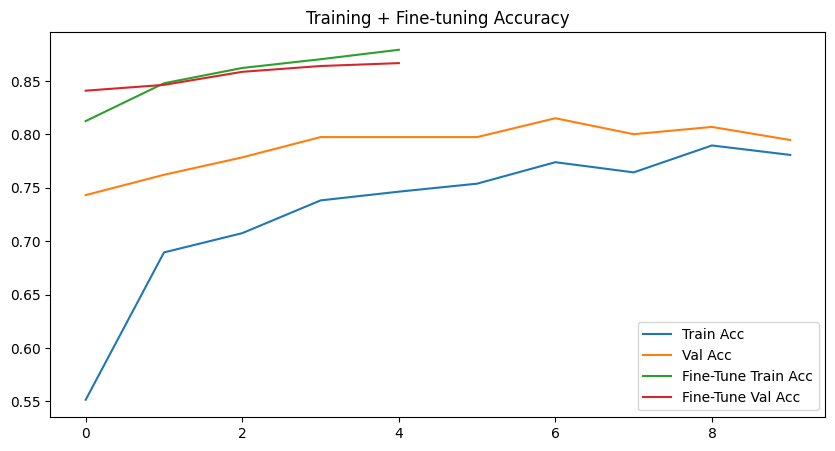

Model saved successfully!


In [11]:
#Question 7: Use a pre-trained VGG16 model (via transfer learning) on a small custom dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model. Include your code and result discussion.

# ============================================================
#          VGG16 Transfer Learning + Fine-Tuning
#     With Automatic Flowers Dataset Download & Split
# ============================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import splitfolders
import os

# ------------------------------------------------------------
# STEP 1 — DOWNLOAD FLOWERS DATASET
# ------------------------------------------------------------
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xvf flower_photos.tgz

# ------------------------------------------------------------
# STEP 2 — SPLIT INTO TRAIN & VAL
# ------------------------------------------------------------
splitfolders.ratio(
    "/content/flower_photos",
    output="/content/dataset",
    seed=42,
    ratio=(.8, .2)
)

train_dir = "/content/dataset/train"
val_dir   = "/content/dataset/val"

# ------------------------------------------------------------
# STEP 3 — DATA GENERATORS
# ------------------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

num_classes = train_gen.num_classes

# ------------------------------------------------------------
# STEP 4 — LOAD VGG16 PRETRAINED MODEL (WITHOUT TOP LAYERS)
# ------------------------------------------------------------
vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in vgg.layers:
    layer.trainable = False   # freeze feature extractor

# ------------------------------------------------------------
# STEP 5 — ADD CUSTOM CLASSIFIER
# ------------------------------------------------------------
x = Flatten()(vgg.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=vgg.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ------------------------------------------------------------
# STEP 6 — TRAIN ONLY THE TOP LAYERS
# ------------------------------------------------------------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

# ------------------------------------------------------------
# STEP 7 — FINE-TUNE THE LAST 4 LAYERS
# ------------------------------------------------------------
for layer in vgg.layers[-4:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

# ------------------------------------------------------------
# STEP 8 — PLOT TRAINING RESULTS
# ------------------------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.plot(history_fine.history['accuracy'], label='Fine-Tune Train Acc')
plt.plot(history_fine.history['val_accuracy'], label='Fine-Tune Val Acc')
plt.legend()
plt.title("Training + Fine-tuning Accuracy")
plt.show()

# ------------------------------------------------------------
# STEP 9 — SAVE MODEL
# ------------------------------------------------------------
model.save("/content/vgg16_finetuned.h5")
print("Model saved successfully!")


--2025-11-27 08:47:35--  https://images.dog.ceo/breeds/hound-afghan/n02088094_1003.jpg
Resolving images.dog.ceo (images.dog.ceo)... 104.21.17.246, 172.67.178.228, 2606:4700:3034::6815:11f6, ...
Connecting to images.dog.ceo (images.dog.ceo)|104.21.17.246|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36593 (36K) [image/jpeg]
Saving to: ‘/content/dog.jpg’

/content/dog.jpg    100%[===================>]  35.74K  --.-KB/s    in 0s      

2025-11-27 08:47:35 (167 MB/s) - ‘/content/dog.jpg’ saved [36593/36593]



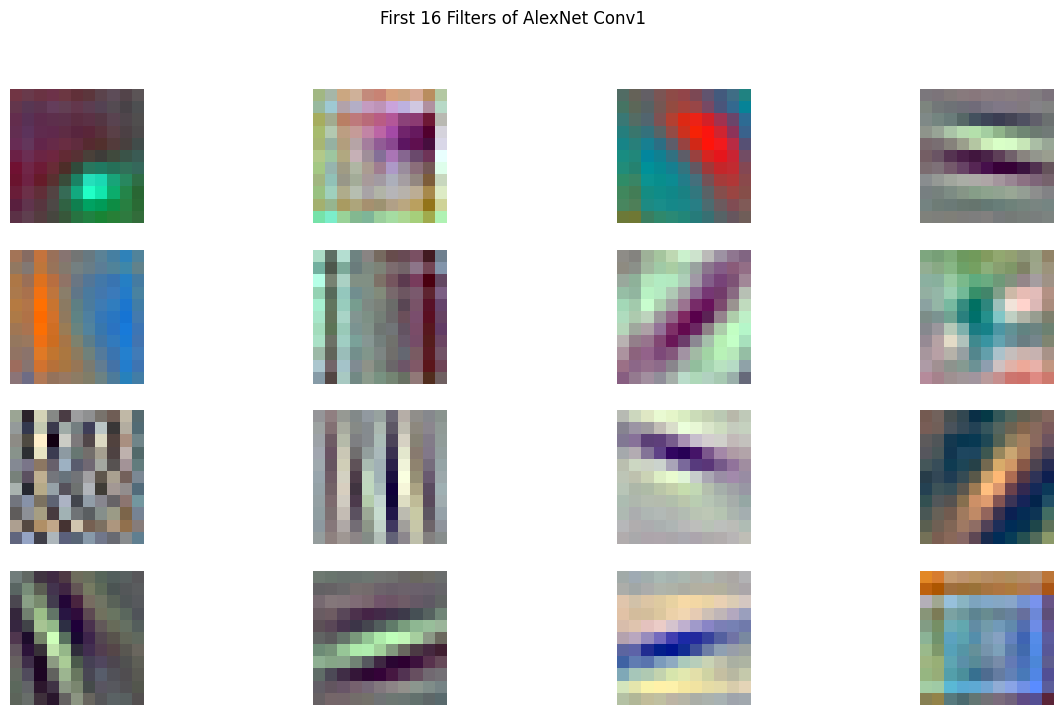

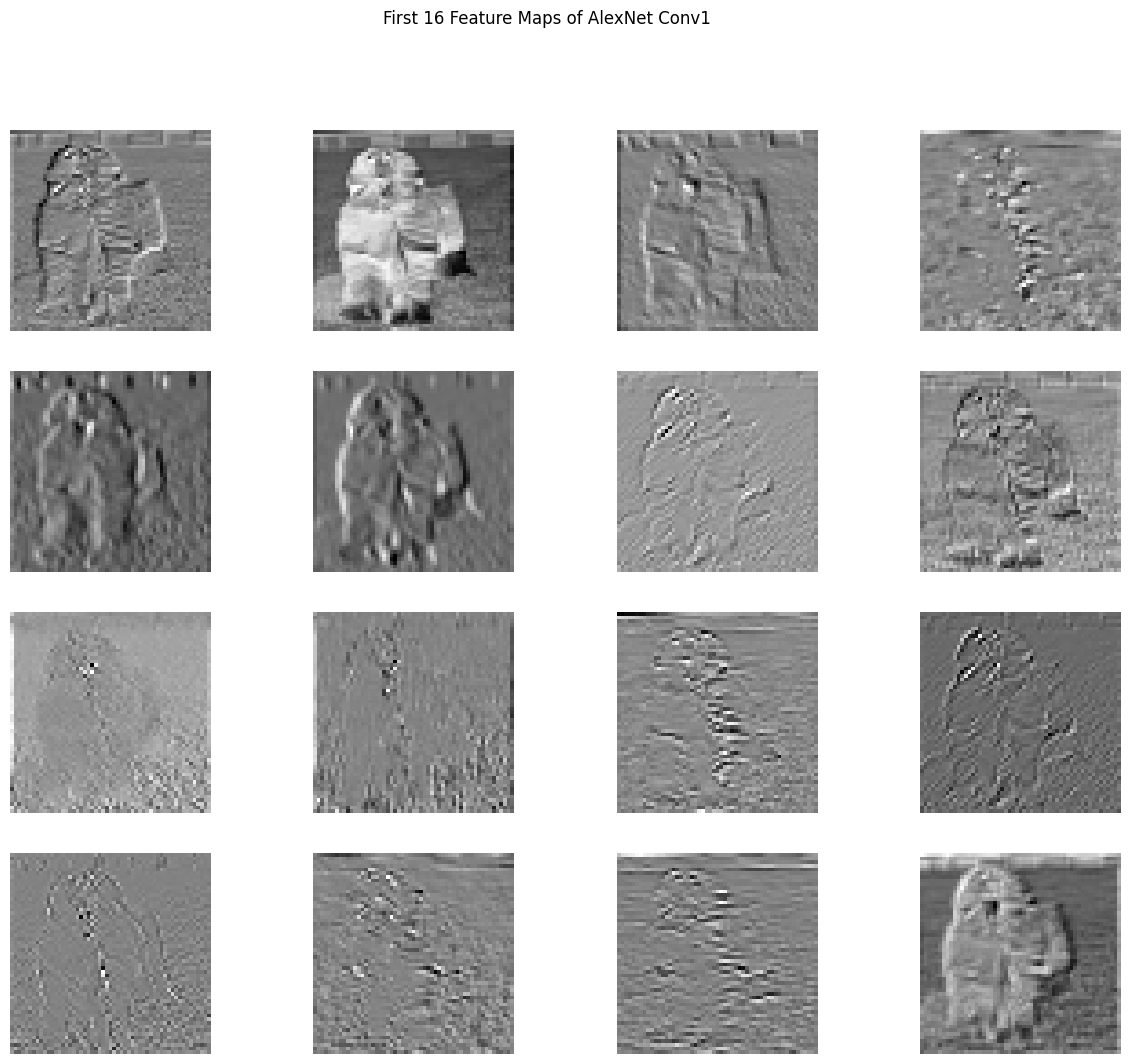

In [16]:
#Question 8: Write a program to visualize the filters and feature maps of the first convolutional layer of AlexNet on an example input image.


#     VISUALIZING FILTERS & FEATURE MAPS OF ALEXNET

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Download a sample image
!wget -O /content/dog.jpg https://images.dog.ceo/breeds/hound-afghan/n02088094_1003.jpg

img_path = "/content/dog.jpg"
img = Image.open(img_path).convert("RGB")


# 1. Load Pretrained AlexNet

alexnet = models.alexnet(weights="AlexNet_Weights.IMAGENET1K_V1")
alexnet.eval()


# 2. Load input image

img_path = "dog.jpg"   # put your image here
img = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img_tensor = transform(img).unsqueeze(0)   # add batch dimension


# 3. Extract first convolution layer

first_conv = alexnet.features[0]    # Conv2d(3, 64, kernel_size=11, stride=4, padding=2)


# 4. Visualize Filters (Kernels)

filters = first_conv.weight.data.clone()

num_filters = filters.shape[0]

plt.figure(figsize=(15, 8))
for i in range(16):  # show first 16 filters
    f = filters[i].cpu().numpy()
    f = (f - f.min()) / (f.max() - f.min())  # normalize

    plt.subplot(4, 4, i+1)
    plt.imshow(np.transpose(f, (1, 2, 0)))
    plt.axis("off")
plt.suptitle("First 16 Filters of AlexNet Conv1")
plt.show()


# 5. Generate Feature Maps

with torch.no_grad():
    feature_maps = first_conv(img_tensor)

feature_maps = feature_maps.squeeze(0)  # remove batch dimension


# 6. Visualize Feature Maps

plt.figure(figsize=(15, 12))
for i in range(16):  # show first 16 feature maps
    fm = feature_maps[i].cpu().numpy()

    plt.subplot(4, 4, i+1)
    plt.imshow(fm, cmap="gray")
    plt.axis("off")

plt.suptitle("First 16 Feature Maps of AlexNet Conv1")
plt.show()



Using device: cuda
Epoch [1/10]  Train Acc: 50.13%  Val Acc: 61.20%
Epoch [2/10]  Train Acc: 69.25%  Val Acc: 73.24%
Epoch [3/10]  Train Acc: 76.34%  Val Acc: 77.16%
Epoch [4/10]  Train Acc: 80.65%  Val Acc: 79.59%
Epoch [5/10]  Train Acc: 83.76%  Val Acc: 82.85%
Epoch [6/10]  Train Acc: 86.02%  Val Acc: 83.67%
Epoch [7/10]  Train Acc: 87.99%  Val Acc: 83.22%
Epoch [8/10]  Train Acc: 89.82%  Val Acc: 84.73%
Epoch [9/10]  Train Acc: 91.34%  Val Acc: 83.31%
Epoch [10/10]  Train Acc: 92.77%  Val Acc: 84.22%


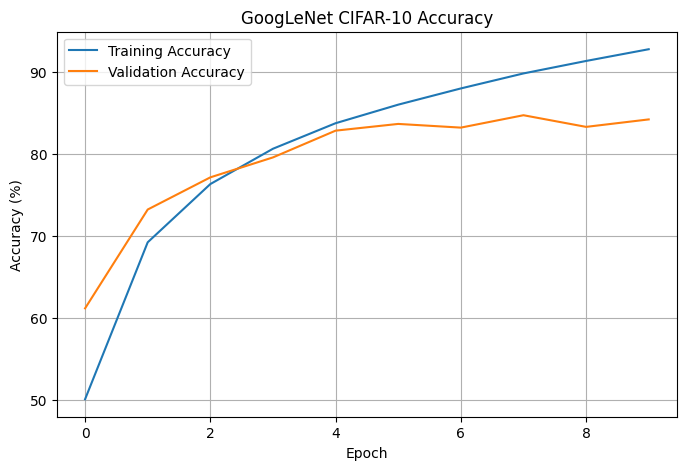

In [23]:
#Question 9: Train a GoogLeNet (Inception v1) or its variant using a standard dataset like CIFAR-10. Plot the training and validation accuracy over epochs and analyze overfitting or underfitting.


# 1. IMPORT LIBRARIES

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.models import googlenet
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# 2. DATASET & DATALOADER

transform = transforms.Compose([
    transforms.Resize((224,224)),        # GoogLeNet expects 224×224
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)


# 3. LOAD GOOGLENET MODEL

model = googlenet(pretrained=False, aux_logits=True, num_classes=10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)


# 4. TRAINING LOOP

train_acc_history = []
val_acc_history = []

epochs = 10

for epoch in range(epochs):
    model.train()
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, aux1, aux2 = model(images)

        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux1, labels)
        loss3 = criterion(aux2, labels)

        loss = loss1 + 0.3*(loss2 + loss3)
        loss.backward()
        optimizer.step()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total
    train_acc_history.append(train_acc)


    # VALIDATION ACCURACY

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100 * correct / total
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]  Train Acc: {train_acc:.2f}%  Val Acc: {val_acc:.2f}%")


# 5. PLOT ACCURACY

plt.figure(figsize=(8,5))
plt.plot(train_acc_history, label="Training Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("GoogLeNet CIFAR-10 Accuracy")
plt.legend()
plt.grid()
plt.show()


**Question 10: You are working in a healthcare AI startup. Your team is tasked with developing a system that automatically classifies medical X-ray images into normal, pneumonia, and COVID-19. Due to limited labeled data, what approach would you suggest using among CNN architectures discussed (e.g., transfer learning with ResNet or Inception variants)? Justify your approach and outline a deployment strategy for production use.**



---

## 🧠 Suggested Approach: Transfer Learning with Pretrained CNNs
- **Use pretrained CNNs (ResNet or Inception variants)**:
  - Pretrained on ImageNet → captures general visual features.
  - Fine-tune later layers on medical X-ray dataset.
- **Why ResNet?**
  - Skip connections mitigate vanishing gradients.
  - Strong performance in medical imaging tasks.
- **Data Augmentation**:
  - Rotations, flips, contrast adjustments, noise injection.
- **Class Imbalance Handling**:
  - Weighted loss functions or oversampling minority classes.

---

## ⚙️ Deployment Strategy for Production Use

### 1. Model Development & Validation
- Train using transfer learning with ResNet50/ResNet101.
- Validate with cross-validation and external datasets.
- Use metrics beyond accuracy: precision, recall, F1-score, ROC-AUC.

### 2. Explainability & Trust
- Integrate **Grad-CAM** or saliency maps.
- Helps radiologists verify model focus on lung regions.

### 3. Scalable Infrastructure
- Deploy as a **REST API microservice** (Flask/FastAPI + Docker).
- Host on cloud platforms (Azure/AWS/GCP) with GPU support.
- Use **Kubernetes** for scaling.

### 4. Integration with Clinical Workflow
- Connect to hospital PACS systems.
- Provide predictions alongside radiologist reports.
- Ensure compliance with **HIPAA/GDPR**.

### 5. Continuous Learning
- Collect new labeled X-rays (esp. COVID variants).
- Retrain/fine-tune periodically.
- Use **active learning** with radiologist feedback.

### 6. Monitoring & Safety
- Monitor model drift and real-world performance.
- Set alerts for low confidence scores.
- Keep human-in-the-loop for final diagnosis.

---

## ✅ Summary
- **Approach**: Transfer learning with **ResNet** + augmentation.
- **Justification**: Handles limited data, robust, proven in medical imaging.
- **Deployment**: Cloud microservice, explainability tools, PACS integration, retraining, compliance.
